# Multiple Linear Regression

if we have more than 1 independent variable we use this 
formula for this is y = m1*x1 + m2*2 + c


In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [7]:
dataset = pd.read_csv(r"C:\Users\Ruhan\regression.csv")
dataset.head()

,age,salary,experience
0,59,126784,24
1,49,106415,17
2,35,76728,9
3,28,57800,2
4,41,102171,16


In [9]:
dataset.shape

(10000, 3)

In [11]:
dataset.isnull().sum()

age           0
salary        0
experience    0
dtype: int64

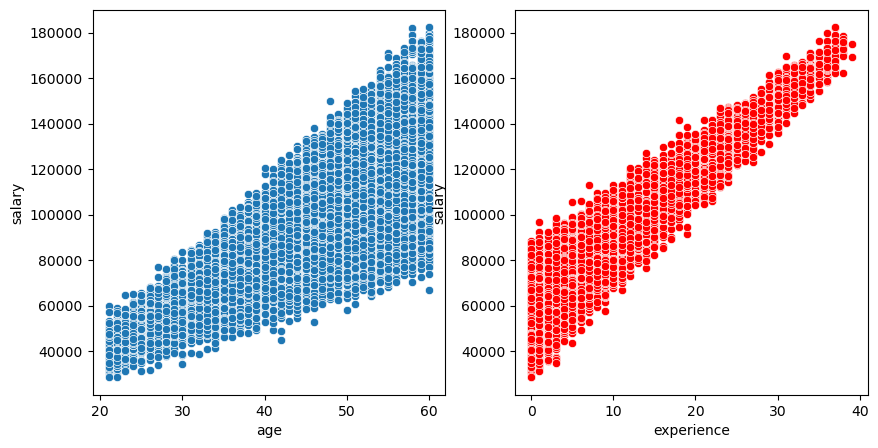

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.scatterplot(x=dataset["age"],y=dataset["salary"])
plt.subplot(1,2,2)
sns.scatterplot(x=dataset["experience"],y=dataset["salary"],c="red")
plt.show()

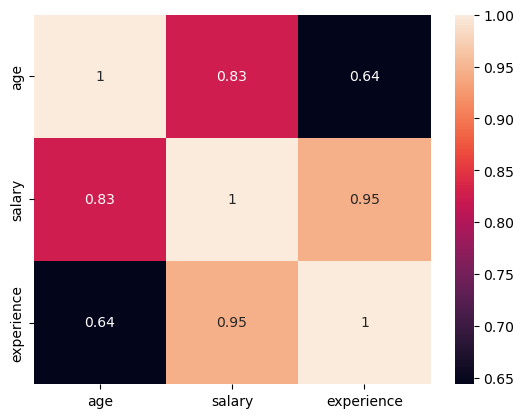

In [19]:
sns.heatmap(data=dataset.corr(),annot=True)
plt.show()

In [31]:
x = dataset.iloc[:, [0, 2]]
y=dataset["salary"]

In [24]:
from sklearn.model_selection import train_test_split

In [32]:
x_Train,x_Test,y_Train,y_Test=train_test_split(x,y,test_size=0.15,random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
lr=LinearRegression()

In [35]:
lr.fit(x_Train,y_Train)

LinearRegression()

In [36]:
lr.score(x_Test,y_Test)

0.9754545061753472

In [40]:
lr.predict([[40,15]])

C:\ProgramData\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([97565.61926269])

In [41]:
lr.coef_

array([ 999.04635858, 2496.80816714])

In [42]:
lr.intercept_

20151.642412521935

In [43]:
x.columns

Index(['age', 'experience'], dtype='object')

In [1]:
#how multireg works
#y=999.04635858*age + 2496.80816714*experience + 20151.642412521935

# Polynomial Regression

formula y= b0 + b1x1 + b2x2^2 + b3x3^3 + ..... bnxn^n  

In [5]:
import pandas as pd
import numpy as np

level = np.arange(1, 201)

salary = 1000 + 50*level + 20*(level**2)

df = pd.DataFrame({
    "Level": level,
    "Salary": salary
})

df.to_csv("polynomial_dataset.csv", index=False)

In [3]:
dataset=pd.read_csv("polynomial_dataset.csv")
dataset.head()
dataset.tail()

,Level,Salary
195,196,779120
196,197,787030
197,198,794980
198,199,802970
199,200,811000


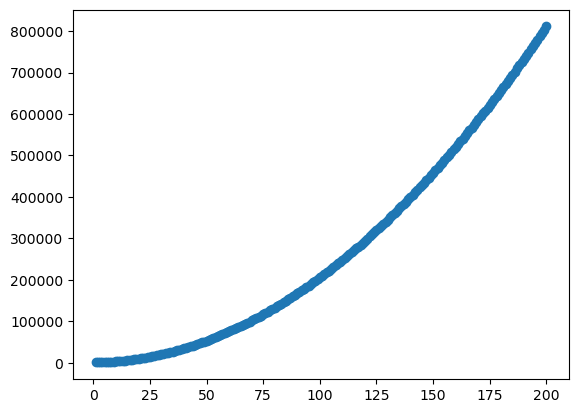

In [3]:
plt.scatter(dataset["Level"],dataset["Salary"])
plt.show()

In [5]:
dataset.corr()

,Level,Salary
Level,1.000000,0.969282
Salary,0.969282,1.000000


In [4]:
x=dataset[["Level"]]
y=dataset["Salary"]

In [5]:
from sklearn.preprocessing import PolynomialFeatures
pl=PolynomialFeatures(degree=2)
pl.fit(x)

PolynomialFeatures()

In [22]:
x=pl.transform(x)

In [9]:
from sklearn.model_selection import train_test_split


In [23]:
x_Train,x_Test,y_Train,y_Test=train_test_split(x,y,test_size=0.15,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

In [24]:
lr = LinearRegression()
lr.fit(x_Train,y_Train)

LinearRegression()

In [25]:
lr.score(x_Test,y_Test)

1.0

In [30]:
prc=lr.predict(x)

In [27]:
lr.coef_

array([ 0., 50., 20.])

In [28]:
lr.intercept_

999.9999999998836

In [29]:
# y= 50*x1 + 20*x2^2 + 999.9999999998836

C:\Users\Ruhan\AppData\Local\Temp\ipykernel_2412\2826783629.py:3: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend("ORG","Pred")


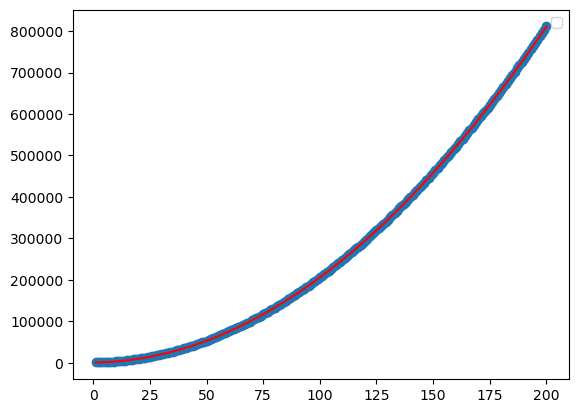

In [32]:
plt.scatter(dataset["Level"],dataset["Salary"])
plt.plot(dataset["Level"],prc,c="red")
plt.legend("ORG","Pred")
plt.show()